In [3]:
import random
import numpy as np
import math
import time 
from matplotlib import pyplot as plt


In [1]:
def decodificar(cromosoma): 
  sgn = cromosoma[0]
  decimal_bin = cromosoma[-4:]
  # Convertir cada bit de string a int antes de multiplicar
  parte_decimal = int(decimal_bin[0]) * (1/2) + int(decimal_bin[1]) * (1/4) + int(decimal_bin[2]) * (1/8) + int(decimal_bin[3]) * (1/16)
  parte_entera = int(cromosoma[1:-4], 2)

  if sgn == '1': 
    return -(parte_entera + parte_decimal)
  else: 
    return  parte_entera + parte_decimal

In [2]:
def ruleta(poblacion, fitness): 
  fitness_total = sum(fitness) 
  probabilidades = []

  for individuo in range(len(poblacion)): 
    prob = fitness[individuo] / fitness_total
    probabilidades.append(prob)

  acumulador = 0
  ruleta = []
  for prob in probabilidades: 
    acumulador += prob
    ruleta.append(acumulador)

  p = random.random()

  for i, probabilidad in enumerate(ruleta): 
    if p <= probabilidad: 
      ganador = i

  return poblacion[ganador]

In [4]:
def competencia(poblacion, fitness, k=2): 
  # elegir k índices al azar
  indices = random.sample(range(len(poblacion)), k)
    
  # buscar el índice del que tenga mejor fitness
  ganador_local = max(indices, key=lambda i: fitness[i])
    
  return poblacion[ganador_local]


In [5]:
def ventanas(poblacion, fitness, n_padres): 
  ordenados = sorted(zip(poblacion, fitness), key=lambda x: x[1], reverse=True)
  padres = []
  N = len(poblacion)

  for i in range(n_padres): 
    # Elegimos el tamaño de la ventana
    q = random.randint(1, N)

    # La ventana sera igual a los mejores q
    ventana = ordenados[:q]

    elegido = random.choice(ventana)
    padres.append(elegido[0])

  return padres 

In [6]:
def cruza(padre1, padre2): 
  punto = random.randint(1, len(padre1)-1)

  hijo1 = padre1[:punto] + padre2[punto:]
  hijo2 = padre2[:punto] + padre1[punto:]

  return hijo1, hijo2

In [7]:
def mutacion(individuo, prob = 0.01): 
  # Incertamos una probabilidad de mutacion ya que no siempre mutamos
  # Por ejemplo con prob = 0.01 cada bit tiene un 1% de cambiar

  prob_i = np.random.rand()
  if prob_i < prob: 
    pos = np.random.choice(len(individuo))
    individuo_mutado = list(individuo)
    if(individuo_mutado[pos] == "0"): 
      individuo_mutado[pos] == "1"
    else: 
      individuo_mutado[pos] = "0"
    
    individuo = "".join(individuo_mutado)
  
  return individuo

In [8]:
def elitismo(poblacion, fitness): 
  elite_index = sorted(range(len(fitness)), key=lambda i: fitness[i], reverse=True)[0]
  return poblacion[elite_index]

In [9]:
def inicializar_poblacion(pop_size, n_bits): 
  poblacion = []
  for _ in range(pop_size): 
    cromosoma = ""
    for _ in range(n_bits): 
      cromosoma += random.choice("01")
    poblacion.append(cromosoma)
  return poblacion

In [18]:
def fitness_function(x, y): 
  return -((x**2 + y**2)**0.25)*((np.sin(50*(x**2 + y**2)**0.1))**2  + 1) # -f2 para obtener la aptitud mínima en vez de máxima


In [35]:
def algoritmo_genetico(fitness_func, pop_size,n_bits, generaciones = 100, max_estable=20): 
  inicio = time.time()
  # 1. Inicializar poblacion
  poblacion = inicializar_poblacion(pop_size, n_bits)

  # Variables de control
  cont_estabilidad = 0
  apt_max = 1e-6
  aptitudes_max = []
  
  # 2. Obtenemos la funcion de aptitud para cada individuo
  for gen in range(generaciones): 
    valores = []
    for ind in poblacion:
      crom_x = ind[:n_bits//2]
      crom_y = ind[n_bits//2:]
      x = decodificar(crom_x)   # convertir cromosoma binario en número real
      y = decodificar(crom_y)
      valores.append((x, y))

    fitness = []
    for (x, y) in valores:
      f = fitness_func(x, y)     # calcular el valor de la función objetivo
      fitness.append(f)
    
    # 3. Elegimos al mejor de la poblacion
    mejor = elitismo(poblacion, fitness)
  
    # 4. Inicializamos la nueva poblacion
    nueva_pob = []

    nueva_pob.append(mejor)

    while(len(nueva_pob) < len(poblacion)): 
      # 5. Realizamos la seleccion
      padre1 = competencia(poblacion, fitness)
      padre2 = competencia(poblacion, fitness)

      # 6. Cruza
      hijo1, hijo2 = cruza(padre1, padre2)

      # 7. Mutacion
      hijo1 = mutacion(hijo1)
      hijo2 = mutacion(hijo2)

      # 8. Lo agregamos a la nueva poblacion
      nueva_pob.append(hijo1)
      if len(nueva_pob) < len(poblacion):  # no pasarse del tamaño
        nueva_pob.append(hijo2)
      
    # 9. Evaluacion de estabilidad
    if np.isclose(max(fitness), apt_max):
      cont_estabilidad += 1
    else:
      cont_estabilidad = 0

    if cont_estabilidad >= max_estable:
      print(f"Se alcanzó estabilidad en la generación {gen}")
      break

    # Actualizar para la siguiente generación
    poblacion = nueva_pob
    aptitudes_max.append(max(fitness))
    apt_max = max(fitness)

  # Seleccionar mejor individuo final
  valores = []
  for ind in poblacion:
    crom_x = ind[:n_bits//2]
    crom_y = ind[n_bits//2:]
    x = decodificar(crom_x)   # convertir cromosoma binario en número real
    y = decodificar(crom_y)
    valores.append((x, y))

  fitness = []
  for (x, y) in valores:
    f = fitness_func(x, y)     # calcular el valor de la función objetivo
    fitness.append(f)
  
  mejor_idx = max(range(len(fitness)), key=lambda i: fitness[i])
  mejor_cromosoma = poblacion[mejor_idx]
  mejor_valor = valores[mejor_idx]
  mejor_fit = fitness[mejor_idx]

  # Gráfico de evolución
  plt.plot(range(len(aptitudes_max)), aptitudes_max)
  plt.xlabel("Generación")
  plt.ylabel("Mejor fitness")
  plt.title(f"Evolución del AG con tamaño de poblacion {pop_size}")
  plt.show()
    
  fin = time.time()
  print(f'El algoritmo terminó en la generación {gen} en {round(fin-inicio,4)} segundos.')

  return mejor_cromosoma


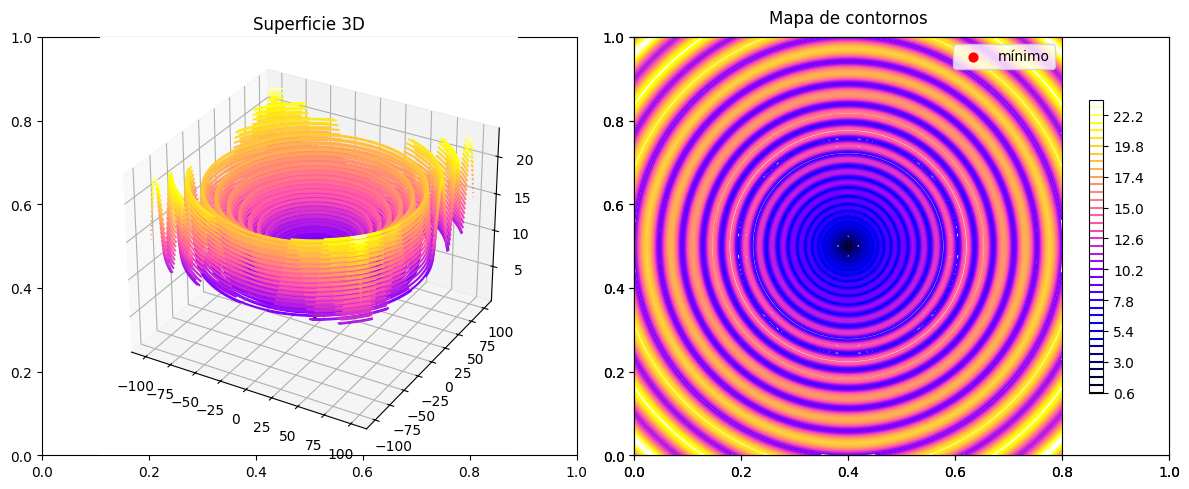

El mínimo de la función está en x = -0.2506, y = -0.2506, valor = 0.620675


In [52]:
def f2(x,y):
    return ((x**2 + y**2)**0.25) * ((np.sin(50*(x**2 + y**2)**0.1))**2 + 1)

# Malla de valores
x = np.linspace(-100, 100, 400)
y = np.linspace(-100, 100, 400)
X, Y = np.meshgrid(x, y)
Z = f2(X, Y)

min_idx = np.unravel_index(np.argmin(Z), Z.shape)
x_min, y_min, z_min = X[min_idx], Y[min_idx], Z[min_idx]


# Crear figura con 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': None})
ax3d = fig.add_subplot(1, 2, 1, projection='3d')
ax2d = fig.add_subplot(1, 2, 2)

# Gráfico 3D
ax3d.contour3D(X, Y, Z, 40, cmap='gnuplot2')
ax3d.set_title("Superficie 3D")

# Gráfico 2D con contornos
ax2d = fig.add_subplot(1, 2, 2)
contour = ax2d.contour(X, Y, Z, 40, cmap='gnuplot2')
ax2d.scatter(x_min, y_min, color="red", s=40, label="mínimo")
fig.colorbar(contour, ax=ax2d, shrink=0.7)
ax2d.set_xticks([]); ax2d.set_yticks([])
ax2d.set_xlabel(""); ax2d.set_ylabel("")
ax2d.legend()
ax2d.set_title("Mapa de contornos", pad=10)
plt.tight_layout()
plt.show()

# Calcular mínimo
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
print(f"El mínimo de la función está en x = {X[min_idx]:.4f}, y = {Y[min_idx]:.4f}, valor = {Z[min_idx]:.6f}")

Se alcanzó estabilidad en la generación 41


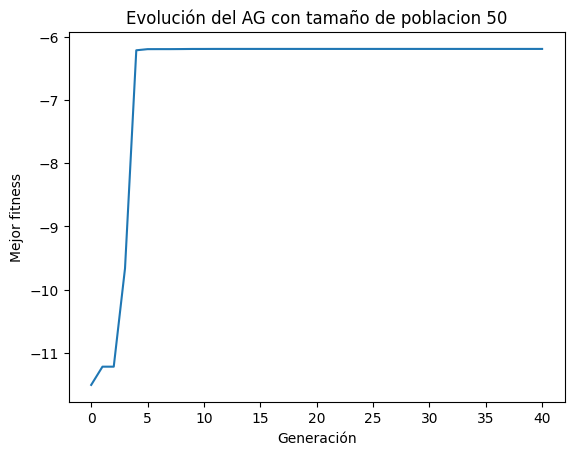

El algoritmo terminó en la generación 41 en 0.0808 segundos.
0000100110010000000000011010
El minimo de la funcione esta en x = 38.25, y = 1.625 y es igual a 6.190252030518073


In [ ]:
ganador = algoritmo_genetico(fitness_function, 50,28, generaciones = 1000, max_estable=30)
print(ganador)
crom_x = ganador[:28//2]
crom_y = ganador[28//2:]
x = decodificar(crom_x)   # convertir cromosoma binario en número real
y = decodificar(crom_y)
print(f"El minimo de la funcione esta en x = {x}, y = {y} y es igual a {f2(x,y)}")

Ejecutando algoritmo genético con pop_size = 20
Se alcanzó estabilidad en la generación 36


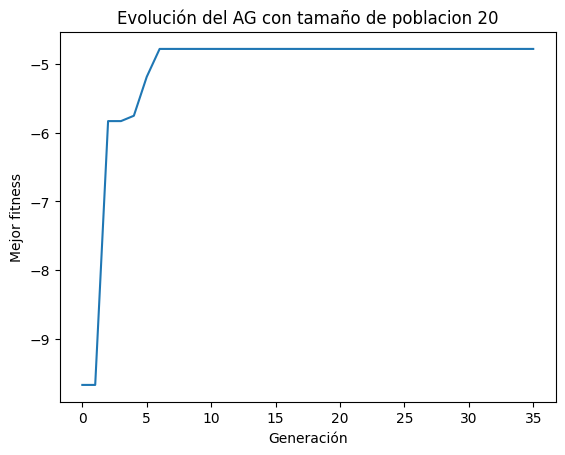

El algoritmo terminó en la generación 36 en 0.0701 segundos.
Mejor cromosoma: 1000001010110010000011000111
El mínimo de la función está en x = -10.7500, y = -12.4375, f2(x,y) = 4.779412
Ejecutando algoritmo genético con pop_size = 50
Se alcanzó estabilidad en la generación 99


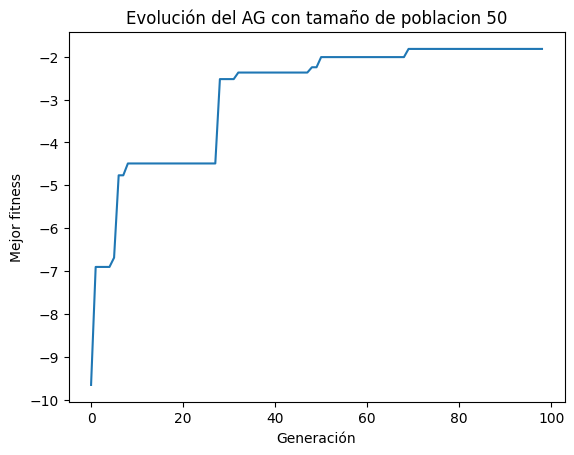

El algoritmo terminó en la generación 99 en 0.0759 segundos.
Mejor cromosoma: 0000000010101000000000011010
El mínimo de la función está en x = 2.6250, y = 1.6250, f2(x,y) = 1.817831
Ejecutando algoritmo genético con pop_size = 100
Se alcanzó estabilidad en la generación 46


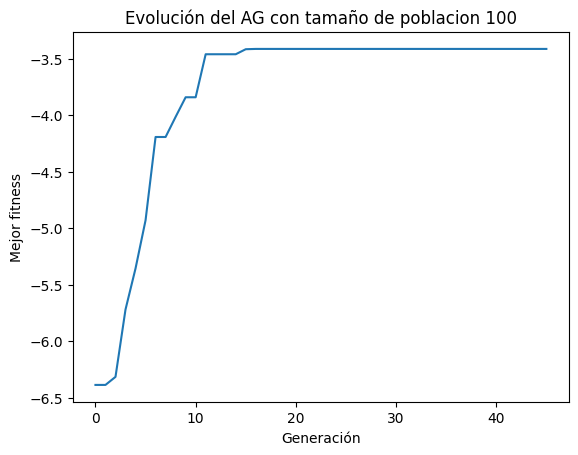

El algoritmo terminó en la generación 46 en 0.0695 segundos.
Mejor cromosoma: 0000000101001110000010100110
El mínimo de la función está en x = 5.1875, y = -10.3750, f2(x,y) = 3.414241
Ejecutando algoritmo genético con pop_size = 200
Se alcanzó estabilidad en la generación 90


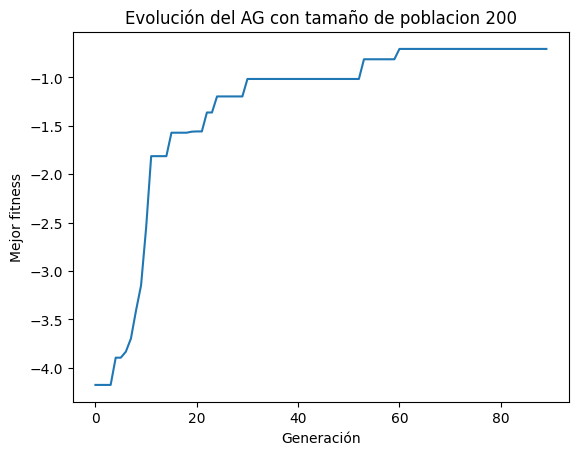

El algoritmo terminó en la generación 90 en 0.1406 segundos.
Mejor cromosoma: 0000000000001000000000000000
El mínimo de la función está en x = 0.1250, y = 0.0000, f2(x,y) = 0.707106


In [38]:
# Probador de algoritmo genético con diferentes tamaños de población

# Lista de tamaños de población que queremos probar
poblaciones = [20, 50, 100, 200]

# Iteramos sobre cada tamaño
for pop_size in poblaciones:
    print("="*60)
    print(f"Ejecutando algoritmo genético con pop_size = {pop_size}")
    
    # Ejecutar el algoritmo
    ganador = algoritmo_genetico(fitness_function, pop_size, 28, generaciones=100, max_estable=30)
    print(f"Mejor cromosoma: {ganador}")
    
    # Dividir cromosoma en x e y
    crom_x = ganador[:28//2]
    crom_y = ganador[28//2:]
    
    # Decodificar
    x = decodificar(crom_x)
    y = decodificar(crom_y)
    
    # Evaluar en la función objetivo f2
    print(f"El mínimo de la función está en x = {x:.4f}, y = {y:.4f}, f2(x,y) = {f2(x,y):.6f}")
